# 📊 Análisis de Resultados - MobileNetV2

In [1]:
import torch
from torchvision import models, transforms
import torch.nn as nn
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import os
import yaml


In [2]:
# Configuración
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

image_size = config["modelo"]["tamaño_imagen"]
batch_size = config["modelo"]["batch_size"]

# Dataset y clases
test_df = pd.read_csv("../data/test.csv")
clases = sorted(test_df["clase_nombre"].unique())
num_classes = len(clases)
class_to_idx = {c: i for i, c in enumerate(clases)}
idx_to_class = {i: c for c, i in class_to_idx.items()}


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.mobilenet_v2(pretrained=False)
model.classifier[1] = nn.Linear(model.last_channel, num_classes)
model.load_state_dict(torch.load("../models/modelo1.pth", map_location=device))
model.to(device)
model.eval()


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [5]:
class InferenceDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        self.data = df
        self.transform = transform
        self.class_to_idx = {c: i for i, c in enumerate(sorted(df["clase_nombre"].unique()))}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img = Image.open(row["imagen_rgb"]).convert("RGB")
        label = self.class_to_idx[row["clase_nombre"]]
        if self.transform:
            img = self.transform(img)
        return img, label

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

ds_test = InferenceDataset(test_df, transform)
dl_test = DataLoader(ds_test, batch_size=batch_size)


                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       1.00      0.67      0.80        15
                                 Apple___Black_rot       0.88      1.00      0.94        15
                          Apple___Cedar_apple_rust       1.00      0.93      0.97        15
                                   Apple___healthy       1.00      0.87      0.93        15
                               Blueberry___healthy       0.94      1.00      0.97        15
          Cherry_(including_sour)___Powdery_mildew       0.94      1.00      0.97        15
                 Cherry_(including_sour)___healthy       0.83      1.00      0.91        15
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.93      0.87      0.90        15
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00        15
               Corn_(maize)___Northern_Leaf_Blight       0.88      1.00      0.

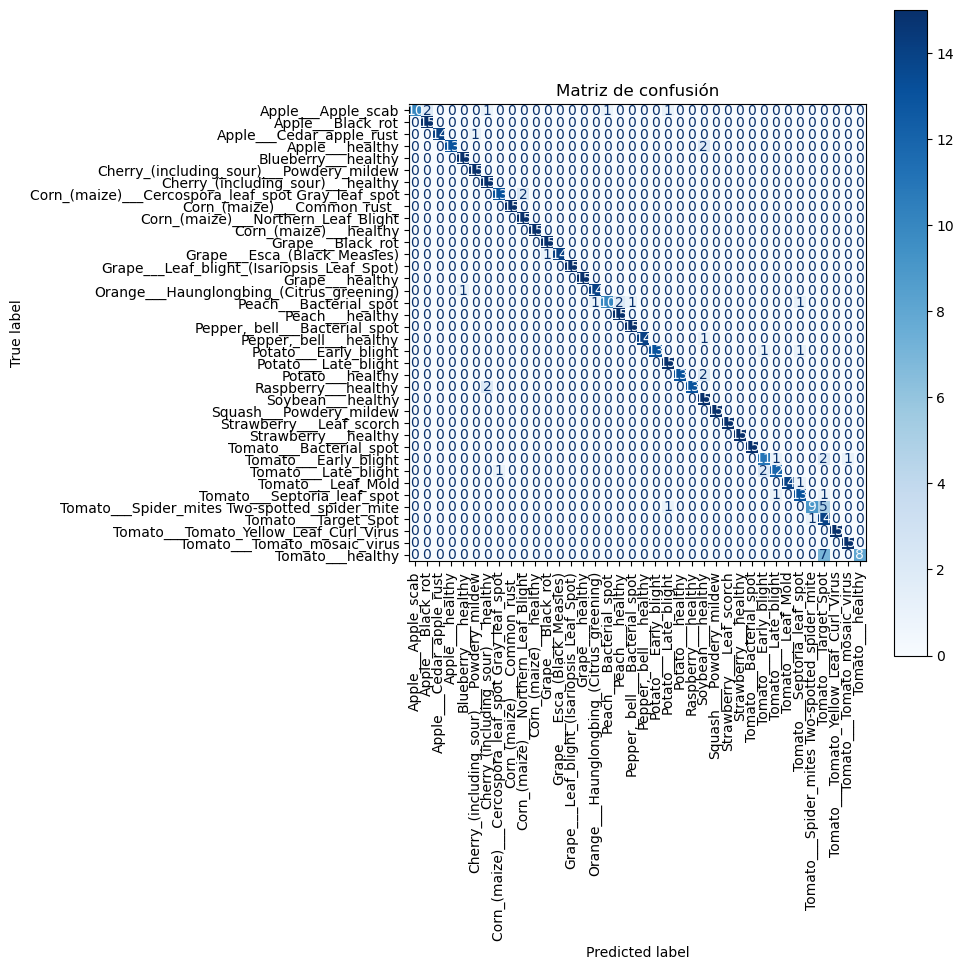

In [6]:
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in dl_test:
        x = x.to(device)
        out = model(x)
        preds = torch.argmax(out, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

# Informe
print(classification_report(all_labels, all_preds, target_names=clases))

# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(xticks_rotation=90, ax=ax, cmap='Blues')
plt.title("Matriz de confusión")
plt.tight_layout()
plt.savefig("../results/confusion_matrix.png")
plt.show()


## 🔍 Ejemplos de predicciones aleatorias

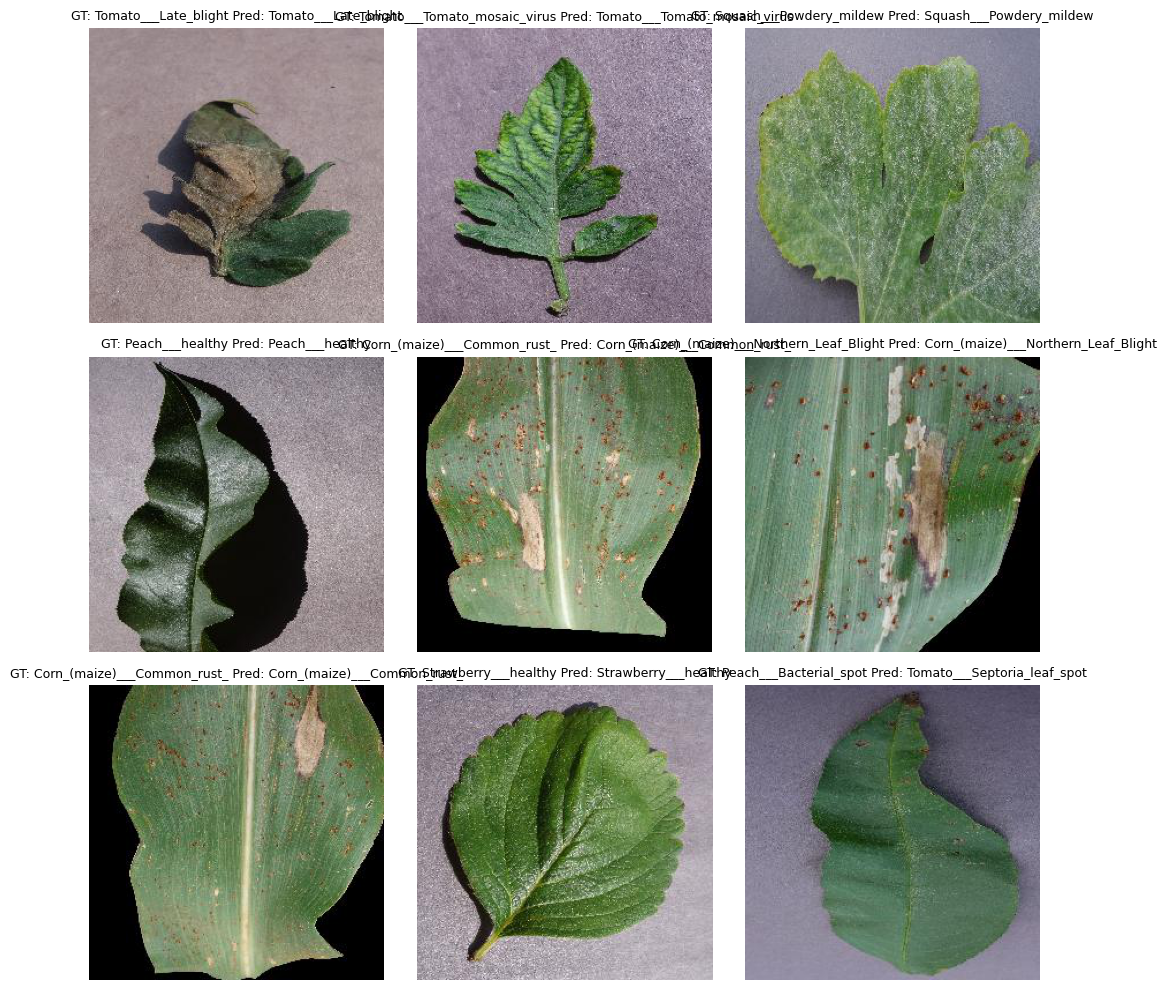

In [8]:
samples = test_df.sample(9).reset_index(drop=True)
fig, axs = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axs.flatten()):
    img = Image.open(samples.loc[i, "imagen_rgb"]).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(input_tensor)
        pred_label = idx_to_class[int(torch.argmax(pred))]
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"GT: {samples.loc[i, 'clase_nombre']} Pred: {pred_label}", fontsize=9)
plt.tight_layout()
plt.show()
